In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
# Gemeinsamen Merge laden und an die bisherigen Analysen anpassen
from pathlib import Path


def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Repository-Wurzel mit .git wurde nicht gefunden.")


MERGED_FILE = (
    find_repo_root()
    / "dataset"
    / "cleaned"
    / "merged"
    / "all_sources_attacks_merged_analysis_ready.csv"
)
if not MERGED_FILE.exists():
    raise FileNotFoundError(
        f"Merge-Datei fehlt: {MERGED_FILE}\n"
        "Bitte zuerst dataset/raw/Merge all files.ipynb vollständig ausführen."
    )

df = pd.read_csv(MERGED_FILE, low_memory=False)
required = {"age_reg", "patient_id", "attack_datetime", "weekday_raw", "headache", "migraine"}
missing = sorted(required - set(df.columns))
if missing:
    raise KeyError(f"Pflichtspalten im gemeinsamen Merge fehlen: {missing}")

rows_before = len(df)
df["age_reg"] = pd.to_numeric(df["age_reg"], errors="coerce")
df = df.loc[df["age_reg"].ge(18)].copy()
df = df.rename(columns={
    "patient_id": "patient_info_id",
    "attack_datetime": "attack_time",
    "weekday_raw": "weekday",
})

bool_map = {
    "true": True, "1": True, "1.0": True, "yes": True, "ja": True, "wahr": True,
    "false": False, "0": False, "0.0": False, "no": False, "nein": False, "falsch": False,
}
for column in [
    "headache", "migraine", "comment_menstruation",
    "symptoms_both_side_headache", "symptoms_one_side_headache",
    "symptoms_pulsating_headache", "symptoms_dull_headache",
]:
    if column in df.columns:
        df[column] = df[column].astype("string").str.strip().str.lower().map(bool_map).astype("boolean")

print("Loaded file:", MERGED_FILE)
print("Zeilen vor Altersfilter:", rows_before)
print("Zeilen nach age_reg >= 18:", len(df))
print("Entfernte Zeilen:", rows_before - len(df))


Loaded file: d:\HS Hof files all sem\HS Hof files Sem 7\Data Anlayse & Mining\Repo\dataset\cleaned\merged\all_sources_attacks_merged_analysis_ready.csv
Zeilen vor Altersfilter: 4066498
Zeilen nach age_reg >= 18: 3956188
Entfernte Zeilen: 110310


In [3]:
df.head()

,attack_id,patient_info_id,source_group,headache,migraine,symptoms_both_side_headache,symptoms_one_side_headache,symptoms_pulsating_headache,symptoms_dull_headache,attack_time,...,attack_date,year,month,month_name,weekday_num,weekday_name,season,week_start,migraine_group,age_group
0,117,72741515,AppOnly,True,False,False,False,True,False,2020-06-08,...,2020-06-08,2020,6,Juni,0,Montag,Sommer,2020-06-08,Nicht-Migraene,30-44
1,118,72741515,AppOnly,True,True,False,False,True,False,2020-06-09,...,2020-06-09,2020,6,Juni,1,Dienstag,Sommer,2020-06-08,Migraene,30-44
2,127,44203359,AppOnly,True,True,False,True,True,False,2020-06-19,...,2020-06-19,2020,6,Juni,4,Freitag,Sommer,2020-06-15,Migraene,45-59
3,128,44203359,AppOnly,True,True,False,True,True,False,2020-06-20,...,2020-06-20,2020,6,Juni,5,Samstag,Sommer,2020-06-15,Migraene,45-59
4,129,44203359,AppOnly,True,True,False,True,True,False,2020-06-21,...,2020-06-21,2020,6,Juni,6,Sonntag,Sommer,2020-06-15,Migraene,45-59


In [4]:
df["patient_info_id"].nunique()

61622

In [5]:
cols = ["attack_time","date_registration","first_app_entry","last_app_entry"]

df[cols] = df[cols].apply(pd.to_datetime, errors="coerce")

In [6]:
df = df[(df["year"] != 2026) & (df["year"] != 2020)]

In [7]:
all_days = pd.date_range(
    start=df["attack_time"].min(),
    end=df["attack_time"].max(),
    freq="D"
)

In [8]:
daily_participants = []

for day in all_days:
    
    active = (
        (df["first_app_entry"] <= day) &
        (df["last_app_entry"] >= day)
    )
    
    n_active = df.loc[
        active,
        "patient_info_id"
    ].nunique()
    
    daily_participants.append(n_active)

In [9]:
daily_participants = pd.Series(
    daily_participants,
    index=all_days
)

In [10]:
migraine_patients = df[df['migraine'] == True]['patient_info_id'].unique()
non_migraine_patients = df[df['migraine'] == False]['patient_info_id'].unique()

# check overlap
overlap = set(migraine_patients) & set(non_migraine_patients)

print(f"Migraine patients: {len(migraine_patients)}")
print(f"Non-migraine patients: {len(non_migraine_patients)}")
print(f"Patients in both groups: {len(overlap)}")

Migraine patients: 45708
Non-migraine patients: 54166
Patients in both groups: 42290


In [11]:
migraine_count = df['migraine'].sum()
non_migraine_count = (df['migraine'] == False).sum()
total = len(df)

print(f"Total attacks: {total}")
print(f"Migraine attacks: {migraine_count} ({migraine_count/total*100:.1f}%)")
print(f"Non-migraine attacks: {non_migraine_count} ({non_migraine_count/total*100:.1f}%)")

Total attacks: 3674729
Migraine attacks: 1482638 (40.3%)
Non-migraine attacks: 2192091 (59.7%)


In [12]:
# split attacks by migraine vs non-migraine
daily_migraine_attacks = (df[df['migraine'] == True]
                          .groupby('attack_time')
                          .size())

daily_non_migraine_attacks = (df[df['migraine'] == False]
                              .groupby('attack_time')
                              .size())

# convert index to datetime
daily_migraine_attacks.index = pd.to_datetime(daily_migraine_attacks.index)
daily_non_migraine_attacks.index = pd.to_datetime(daily_non_migraine_attacks.index)

# reindex to complete date range
daily_migraine_attacks = daily_migraine_attacks.reindex(all_days, fill_value=0)
daily_non_migraine_attacks = daily_non_migraine_attacks.reindex(all_days, fill_value=0)

# calculate daily rates using same daily_participants
daily_rate_migraine     = daily_migraine_attacks / daily_participants
daily_rate_non_migraine = daily_non_migraine_attacks / daily_participants

print("Migraine daily rate:")
print(daily_rate_migraine.head())
print("\nNon-migraine daily rate:")
print(daily_rate_non_migraine.head())

Migraine daily rate:
2021-01-01    0.127701
2021-01-02    0.083658
2021-01-03    0.078695
2021-01-04    0.094340
2021-01-05    0.093458
Freq: D, dtype: float64

Non-migraine daily rate:
2021-01-01    0.204322
2021-01-02    0.178988
2021-01-03    0.190019
2021-01-04    0.188679
2021-01-05    0.216822
Freq: D, dtype: float64


In [13]:
monthly_migraine = daily_rate_migraine.groupby(daily_rate_migraine.index.month).mean()
monthly_non_migraine = daily_rate_non_migraine.groupby(daily_rate_non_migraine.index.month).mean()

print("Monthly migraine:")
print(monthly_migraine.round(4))
print("\nMonthly non-migraine:")
print(monthly_non_migraine.round(4))

Monthly migraine:
1     0.0897
2     0.0918
3     0.0934
4     0.0943
5     0.0935
6     0.0924
7     0.0926
8     0.0908
9     0.0925
10    0.0926
11    0.0915
12    0.0899
dtype: float64

Monthly non-migraine:
1     0.1622
2     0.1633
3     0.1578
4     0.1522
5     0.1466
6     0.1430
7     0.1450
8     0.1423
9     0.1468
10    0.1486
11    0.1486
12    0.1432
dtype: float64


In [14]:
weekly_migraine = daily_rate_migraine.groupby(daily_rate_migraine.index.dayofweek).mean()
weekly_non_migraine = daily_rate_non_migraine.groupby(daily_rate_non_migraine.index.dayofweek).mean()

print("Weekly migraine:")
print(weekly_migraine.round(4))
print("\nWeekly non-migraine:")
print(weekly_non_migraine.round(4))

Weekly migraine:
0    0.0846
1    0.0896
2    0.0963
3    0.0966
4    0.0960
5    0.0958
6    0.0856
dtype: float64

Weekly non-migraine:
0    0.1484
1    0.1512
2    0.1539
3    0.1528
4    0.1502
5    0.1496
6    0.1431
dtype: float64


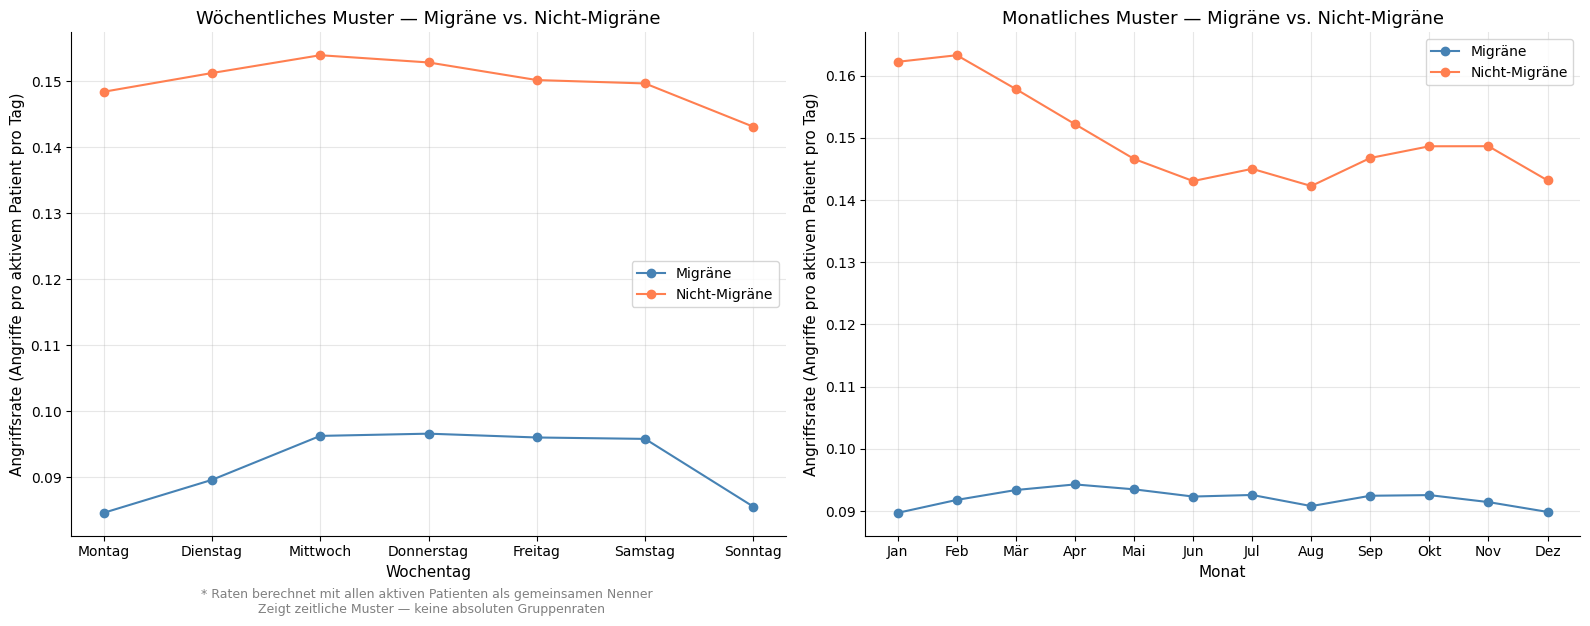

In [15]:
days = ['Montag', 'Dienstag', 'Mittwoch', 'Donnerstag', 'Freitag', 'Samstag', 'Sonntag']
months = ['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun',
          'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Wöchentlich ───────────────────────────────────────
axes[0].plot(days, weekly_migraine.values,
             marker='o', color='steelblue',
             linewidth=1.5, label='Migräne')
axes[0].plot(days, weekly_non_migraine.values,
             marker='o', color='coral',
             linewidth=1.5, label='Nicht-Migräne')
axes[0].set_title('Wöchentliches Muster — Migräne vs. Nicht-Migräne', fontsize=13)
axes[0].set_xlabel('Wochentag', fontsize=11)
axes[0].set_ylabel('Angriffsrate (Angriffe pro aktivem Patient pro Tag)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(True, alpha=0.3)

# ── Monatlich ─────────────────────────────────────────
axes[1].plot(months, monthly_migraine.values,
             marker='o', color='steelblue',
             linewidth=1.5, label='Migräne')
axes[1].plot(months, monthly_non_migraine.values,
             marker='o', color='coral',
             linewidth=1.5, label='Nicht-Migräne')
axes[1].set_title('Monatliches Muster — Migräne vs. Nicht-Migräne', fontsize=13)
axes[1].set_xlabel('Monat', fontsize=11)
axes[1].set_ylabel('Angriffsrate (Angriffe pro aktivem Patient pro Tag)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(True, alpha=0.3)

# Hinweis
fig.text(0.27, -0.03,
         '* Raten berechnet mit allen aktiven Patienten als gemeinsamen Nenner\n'
         '  Zeigt zeitliche Muster — keine absoluten Gruppenraten',
         ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

In [16]:
from scipy import stats

# ── Weekly Kruskal-Wallis ─────────────────────────────
# migraine
groups_w_mig = [daily_rate_migraine[daily_rate_migraine.index.dayofweek == day].values
                for day in range(7)]
stat_w_mig, p_w_mig = stats.kruskal(*groups_w_mig)

# non-migraine
groups_w_non = [daily_rate_non_migraine[daily_rate_non_migraine.index.dayofweek == day].values
                for day in range(7)]
stat_w_non, p_w_non = stats.kruskal(*groups_w_non)

print("Weekly Kruskal-Wallis:")
print(f"Migraine     H={stat_w_mig:.4f}, p={p_w_mig:.4f}")
print(f"Non-migraine H={stat_w_non:.4f}, p={p_w_non:.4f}")

# ── Monthly Kruskal-Wallis ────────────────────────────
# migraine
groups_m_mig = [daily_rate_migraine[daily_rate_migraine.index.month == month].values
                for month in range(1, 13)]
stat_m_mig, p_m_mig = stats.kruskal(*groups_m_mig)

# non-migraine
groups_m_non = [daily_rate_non_migraine[daily_rate_non_migraine.index.month == month].values
                for month in range(1, 13)]
stat_m_non, p_m_non = stats.kruskal(*groups_m_non)

print("\nMonthly Kruskal-Wallis:")
print(f"Migraine     H={stat_m_mig:.4f}, p={p_m_mig:.4f}")
print(f"Non-migraine H={stat_m_non:.4f}, p={p_m_non:.4f}")

Weekly Kruskal-Wallis:
Migraine     H=470.2984, p=0.0000
Non-migraine H=58.8057, p=0.0000

Monthly Kruskal-Wallis:
Migraine     H=25.0872, p=0.0089
Non-migraine H=171.8617, p=0.0000


In [17]:
pip install scikit_posthocs

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import scikit_posthocs as sp

# ── Weekly Dunn — Migraine only (non-migraine not significant) ────────────────
dunn_weekly_mig = sp.posthoc_dunn(
    [daily_rate_migraine[daily_rate_migraine.index.dayofweek == day].values
     for day in range(7)],
    p_adjust='bonferroni'
)
dunn_weekly_mig.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dunn_weekly_mig.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
print("Weekly Dunn — Migraine:")
print(dunn_weekly_mig.round(4))

# ── Monthly Dunn — both groups ────────────────────────────────────────────────
dunn_monthly_mig = sp.posthoc_dunn(
    [daily_rate_migraine[daily_rate_migraine.index.month == month].values
     for month in range(1, 13)],
    p_adjust='bonferroni'
)
dunn_monthly_mig.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
dunn_monthly_mig.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                             'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
print("\nMonthly Dunn — Migraine:")
print(dunn_monthly_mig.round(4))

dunn_monthly_non = sp.posthoc_dunn(
    [daily_rate_non_migraine[daily_rate_non_migraine.index.month == month].values
     for month in range(1, 13)],
    p_adjust='bonferroni'
)
dunn_monthly_non.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
dunn_monthly_non.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                             'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
print("\nMonthly Dunn — Non-migraine:")
print(dunn_monthly_non.round(4))

Weekly Dunn — Migraine:
     Mon  Tue  Wed  Thu  Fri  Sat  Sun
Mon  1.0  0.0  0.0  0.0  0.0  0.0  1.0
Tue  0.0  1.0  0.0  0.0  0.0  0.0  0.0
Wed  0.0  0.0  1.0  1.0  1.0  1.0  0.0
Thu  0.0  0.0  1.0  1.0  1.0  1.0  0.0
Fri  0.0  0.0  1.0  1.0  1.0  1.0  0.0
Sat  0.0  0.0  1.0  1.0  1.0  1.0  0.0
Sun  1.0  0.0  0.0  0.0  0.0  0.0  1.0

Monthly Dunn — Migraine:
        Jan  Feb     Mar     Apr     May  Jun  Jul     Aug  Sep  Oct  Nov  \
Jan  1.0000  1.0  0.4211  0.0418  0.9346  1.0  1.0  1.0000  1.0  1.0  1.0   
Feb  1.0000  1.0  1.0000  1.0000  1.0000  1.0  1.0  1.0000  1.0  1.0  1.0   
Mar  0.4211  1.0  1.0000  1.0000  1.0000  1.0  1.0  1.0000  1.0  1.0  1.0   
Apr  0.0418  1.0  1.0000  1.0000  1.0000  1.0  1.0  0.4635  1.0  1.0  1.0   
May  0.9346  1.0  1.0000  1.0000  1.0000  1.0  1.0  1.0000  1.0  1.0  1.0   
Jun  1.0000  1.0  1.0000  1.0000  1.0000  1.0  1.0  1.0000  1.0  1.0  1.0   
Jul  1.0000  1.0  1.0000  1.0000  1.0000  1.0  1.0  1.0000  1.0  1.0  1.0   
Aug  1.0000  1.0  1.00

In [19]:
print(df['intensity'].describe())
print(df['intensity'].value_counts().sort_index())

count    3.674729e+06
mean     4.559471e+00
std      2.275140e+00
min      0.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      6.000000e+00
max      1.000000e+01
Name: intensity, dtype: float64
intensity
0      25496
1     260967
2     463943
3     595508
4     581253
5     524879
6     429936
7     351408
8     259621
9     103584
10     78134
Name: count, dtype: int64


In [20]:
intensity_migraine = df[df['migraine'] == True]['intensity']
intensity_non_migraine = df[df['migraine'] == False]['intensity']

print("Migraine intensity:")
print(intensity_migraine.describe().round(3))
print("\nNon-migraine intensity:")
print(intensity_non_migraine.describe().round(3))

Migraine intensity:
count    1482638.000
mean           5.555
std            2.238
min            0.000
25%            4.000
50%            6.000
75%            7.000
max           10.000
Name: intensity, dtype: float64

Non-migraine intensity:
count    2192091.000
mean           3.886
std            2.041
min            0.000
25%            2.000
50%            4.000
75%            5.000
max           10.000
Name: intensity, dtype: float64


In [21]:
from scipy import stats

stat, p = stats.mannwhitneyu(intensity_migraine, 
                              intensity_non_migraine,
                              alternative='two-sided')

print(f"Mann-Whitney U statistic: {stat:.2f}")
print(f"p-value: {p:.4f}")

Mann-Whitney U statistic: 2309879438561.00
p-value: 0.0000


In [22]:
print("Migraine duration:")
print(df[df['migraine'] == True]['duration'].describe().round(3))
print("\nNon-migraine duration:")
print(df[df['migraine'] == False]['duration'].describe().round(3))

Migraine duration:
count    1482638.000
mean         644.023
std          411.957
min           60.000
25%          300.000
50%          540.000
75%          900.000
max         1440.000
Name: duration, dtype: float64

Non-migraine duration:
count    2192091.000
mean         557.507
std          412.118
min           60.000
25%          240.000
50%          420.000
75%          720.000
max         1440.000
Name: duration, dtype: float64


In [23]:
duration_migraine = df[df['migraine'] == True]['duration']
duration_non_migraine = df[df['migraine'] == False]['duration']

stat, p = stats.mannwhitneyu(duration_migraine,
                              duration_non_migraine,
                              alternative='two-sided')

print(f"Mann-Whitney U statistic: {stat:.2f}")
print(f"p-value: {p:.4f}")

Mann-Whitney U statistic: 1870482954479.00
p-value: 0.0000


In [24]:
import numpy as np

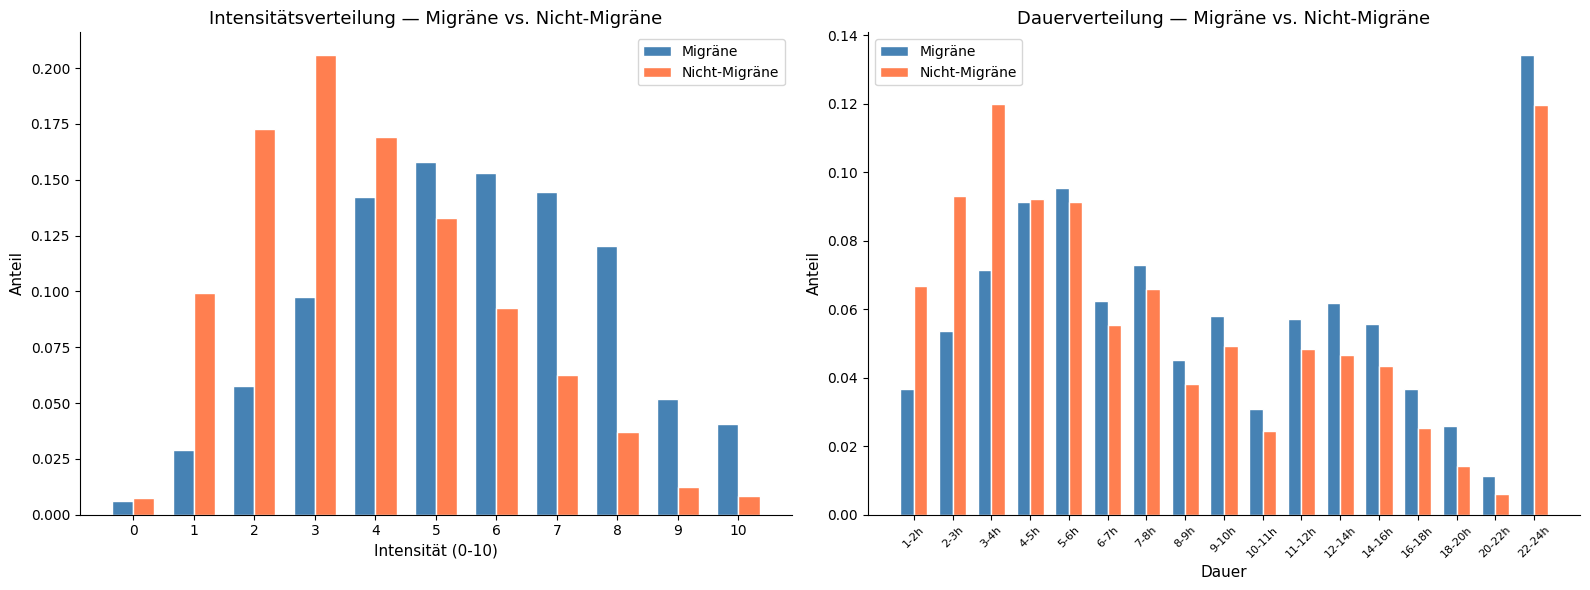

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Intensität ────────────────────────────────────────
intensity_values = range(11)
mig_props = [((intensity_migraine == i).sum() / len(intensity_migraine)) 
             for i in intensity_values]
non_props = [((intensity_non_migraine == i).sum() / len(intensity_non_migraine)) 
             for i in intensity_values]
x = np.arange(11)
width = 0.35

axes[0].bar(x - width/2, mig_props, width,
            color='steelblue', label='Migräne', edgecolor='white')
axes[0].bar(x + width/2, non_props, width,
            color='coral', label='Nicht-Migräne', edgecolor='white')
axes[0].set_title('Intensitätsverteilung — Migräne vs. Nicht-Migräne', fontsize=13)
axes[0].set_xlabel('Intensität (0-10)', fontsize=11)
axes[0].set_ylabel('Anteil', fontsize=11)
axes[0].set_xticks(x)
axes[0].legend(fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Dauer ─────────────────────────────────────────────
duration_bins = [60, 120, 180, 240, 300, 360, 420, 480, 540, 
                 600, 660, 720, 840, 960, 1080, 1200, 1320, 1440]
duration_labels = ['1-2h', '2-3h', '3-4h', '4-5h', '5-6h', 
                   '6-7h', '7-8h', '8-9h', '9-10h', '10-11h', 
                   '11-12h', '12-14h', '14-16h', '16-18h', 
                   '18-20h', '20-22h', '22-24h']

mig_dur = pd.cut(duration_migraine, bins=duration_bins)\
            .value_counts(normalize=True)\
            .reindex(pd.cut(duration_migraine, bins=duration_bins).cat.categories)
non_dur = pd.cut(duration_non_migraine, bins=duration_bins)\
            .value_counts(normalize=True)\
            .reindex(pd.cut(duration_non_migraine, bins=duration_bins).cat.categories)

x2 = np.arange(len(duration_bins)-1)

axes[1].bar(x2 - width/2, mig_dur.values, width,
            color='steelblue', label='Migräne', edgecolor='white')
axes[1].bar(x2 + width/2, non_dur.values, width,
            color='coral', label='Nicht-Migräne', edgecolor='white')
axes[1].set_title('Dauerverteilung — Migräne vs. Nicht-Migräne', fontsize=13)
axes[1].set_xlabel('Dauer', fontsize=11)
axes[1].set_ylabel('Anteil', fontsize=11)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(duration_labels, rotation=45, fontsize=8)
axes[1].legend(fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()